# 🫀 Klasifikasi Multi-Kelas Tingkat Keparahan Penyakit Jantung
## UCI Heart Disease Dataset — Random Forest Classifier

**Deskripsi Proyek:**  
Notebook ini membangun model Machine Learning untuk memprediksi **tingkat keparahan penyakit jantung** pada skala **0 sampai 4**, di mana:
- `0` = Tidak ada penyakit jantung
- `1–4` = Tingkat keparahan meningkat

**Sumber Data:** UCI Machine Learning Repository — Heart Disease Dataset  
**Dataset yang digunakan:** Cleveland + Hungarian (digabungkan, total ±597 baris)  
**Algoritma:** Random Forest Classifier (Multi-class)

---

## 📦 SEL 1: Import Library

In [1]:
# ============================================================
# SEL 1 — IMPORT SEMUA LIBRARY YANG DIBUTUHKAN
# ============================================================

# --- Manipulasi & Analisis Data ---
import pandas as pd
import numpy as np

# --- Visualisasi ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing & Splitting ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Model Machine Learning ---
from sklearn.ensemble import RandomForestClassifier

# --- Evaluasi Model ---
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# --- Konfigurasi Tampilan ---
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set style visualisasi
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print('✅ Semua library berhasil diimport.')

✅ Semua library berhasil diimport.


---
## 📂 SEL 2: Data Loading & Penggabungan Dataset

In [2]:
# ============================================================
# SEL 2 — LOADING DATA
# Dataset UCI Heart Disease tidak memiliki header.
# Kolom didefinisikan secara manual sesuai dokumentasi UCI.
# '?' adalah penanda missing value pada dataset ini.
# ============================================================

# Definisi nama 14 kolom sesuai dokumentasi UCI Heart Disease
COLUMN_NAMES = [
    'age',       # Usia pasien (tahun)
    'sex',       # Jenis kelamin (1=laki-laki, 0=perempuan)
    'cp',        # Tipe nyeri dada (1-4)
    'trestbps',  # Tekanan darah saat istirahat (mm Hg)
    'chol',      # Kolesterol serum (mg/dl)
    'fbs',       # Gula darah puasa > 120 mg/dl (1=ya, 0=tidak)
    'restecg',   # Hasil EKG saat istirahat (0-2)
    'thalach',   # Detak jantung maksimum yang dicapai
    'exang',     # Angina yang dipicu olahraga (1=ya, 0=tidak)
    'oldpeak',   # Depresi ST akibat olahraga vs istirahat
    'slope',     # Kemiringan segmen ST saat olahraga puncak
    'ca',        # Jumlah pembuluh darah utama (0-3) dari fluoroskopi
    'thal',      # Thalassemia (3=normal, 6=cacat tetap, 7=cacat reversibel)
    'target'     # Tingkat keparahan penyakit jantung (0-4) — LABEL TARGET
]

# --- Load Dataset Cleveland ---
# Dataset utama dengan 303 baris dan kelas target 0-4
df_cleveland = pd.read_csv(
    'processed.cleveland.data',
    names=COLUMN_NAMES,
    na_values='?'   # Konversi '?' menjadi NaN agar mudah diproses
)

# --- Load Dataset Hungarian ---
# Dataset tambahan untuk memperbanyak sampel (294 baris)
df_hungarian = pd.read_csv(
    'processed.hungarian.data',
    names=COLUMN_NAMES,
    na_values='?'
)

# --- Gabungkan Kedua Dataset ---
df = pd.concat([df_cleveland, df_hungarian], ignore_index=True)

print(f'📊 Dataset Cleveland  : {df_cleveland.shape[0]} baris x {df_cleveland.shape[1]} kolom')
print(f'📊 Dataset Hungarian  : {df_hungarian.shape[0]} baris x {df_hungarian.shape[1]} kolom')
print(f'📊 Dataset Gabungan   : {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'\n✅ Total data di atas 300 baris — memenuhi syarat.')

📊 Dataset Cleveland  : 303 baris x 14 kolom
📊 Dataset Hungarian  : 294 baris x 14 kolom
📊 Dataset Gabungan   : 597 baris x 14 kolom

✅ Total data di atas 300 baris — memenuhi syarat.


---
## 🔍 SEL 3: Eksplorasi Awal Dataset

In [3]:
# ============================================================
# SEL 3 — EKSPLORASI AWAL DATASET
# Menampilkan struktur dasar data sebelum preprocessing.
# ============================================================

print('=' * 55)
print('  5 BARIS PERTAMA DATASET')
print('=' * 55)
display(df.head())

print('\n' + '=' * 55)
print('  INFO TIPE DATA & JUMLAH NON-NULL')
print('=' * 55)
df.info()

print('\n' + '=' * 55)
print('  STATISTIK DESKRIPTIF')
print('=' * 55)
display(df.describe())

print('\n' + '=' * 55)
print('  JUMLAH MISSING VALUE PER KOLOM')
print('=' * 55)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
display(missing_df[missing_df['Jumlah Missing'] > 0])

  5 BARIS PERTAMA DATASET


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.00,1.00,1.00,145.00,233.00,1.00,2.00,150.00,0.00,2.30,3.00,0.00,6.00,0
1,67.00,1.00,4.00,160.00,286.00,0.00,2.00,108.00,1.00,1.50,2.00,3.00,3.00,2
2,67.00,1.00,4.00,120.00,229.00,0.00,2.00,129.00,1.00,2.60,2.00,2.00,7.00,1
3,37.00,1.00,3.00,130.00,250.00,0.00,0.00,187.00,0.00,3.50,3.00,0.00,3.00,0
4,41.00,0.00,2.00,130.00,204.00,0.00,2.00,172.00,0.00,1.40,1.00,0.00,3.00,0



  INFO TIPE DATA & JUMLAH NON-NULL
<class 'pandas.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       597 non-null    float64
 1   sex       597 non-null    float64
 2   cp        597 non-null    float64
 3   trestbps  596 non-null    float64
 4   chol      574 non-null    float64
 5   fbs       589 non-null    float64
 6   restecg   596 non-null    float64
 7   thalach   596 non-null    float64
 8   exang     596 non-null    float64
 9   oldpeak   597 non-null    float64
 10  slope     407 non-null    float64
 11  ca        302 non-null    float64
 12  thal      329 non-null    float64
 13  target    597 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 65.4 KB

  STATISTIK DESKRIPTIF


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,597.00,597.00,597.00,596.00,574.00,589.00,596.00,596.00,596.00,597.00,407.00,302.00,329.00,597.00
mean,51.18,0.70,3.07,132.13,248.66,0.11,0.61,144.46,0.32,0.82,1.68,0.67,4.81,0.65
std,9.07,0.46,0.97,17.60,59.78,0.31,0.87,23.79,0.47,1.07,0.57,0.94,1.93,0.98
min,28.00,0.00,1.00,92.00,85.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,44.00,0.00,2.00,120.00,211.00,0.00,0.00,128.00,0.00,0.00,1.00,0.00,3.00,0.00
50%,52.00,1.00,3.00,130.00,242.50,0.00,0.00,146.00,0.00,0.20,2.00,0.00,3.00,0.00
75%,58.00,1.00,4.00,140.00,278.75,0.00,2.00,162.00,1.00,1.50,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,603.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,4.00



  JUMLAH MISSING VALUE PER KOLOM


,Jumlah Missing,Persentase (%)
trestbps,1,0.17
chol,23,3.85
fbs,8,1.34
restecg,1,0.17
thalach,1,0.17
exang,1,0.17
slope,190,31.83
ca,295,49.41
thal,268,44.89


---
## 🧹 SEL 4: Penanganan Missing Values (Imputasi)

In [4]:
# ============================================================
# SEL 4 — PENANGANAN MISSING VALUES (IMPUTASI)
#
# Strategi imputasi:
#  - Fitur KONTINU (trestbps, chol, thalach, oldpeak)
#    → Imputasi dengan MEDIAN (robust terhadap outlier)
#  - Fitur KATEGORIKAL (fbs, restecg, exang, slope, ca, thal)
#    → Imputasi dengan MODUS (nilai yang paling sering muncul)
#
# Keuntungan: jumlah baris tetap tidak berkurang.
# ============================================================

# Kolom kontinu yang akan diisi dengan median
KONTINYU_COLS = ['trestbps', 'chol', 'thalach', 'oldpeak']

# Kolom kategorikal yang akan diisi dengan modus
KATEGORIKAL_COLS = ['fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print('--- Imputasi Fitur Kontinu (Median) ---')
for col in KONTINYU_COLS:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  [{col}] diisi dengan median = {median_val:.2f}')

print('\n--- Imputasi Fitur Kategorikal (Modus) ---')
for col in KATEGORIKAL_COLS:
    if df[col].isnull().sum() > 0:
        modus_val = df[col].mode()[0]
        df[col].fillna(modus_val, inplace=True)
        print(f'  [{col}] diisi dengan modus = {modus_val}')

# Pastikan tipe data target adalah integer
df['target'] = df['target'].astype(int)

print(f'\n✅ Total missing value setelah imputasi : {df.isnull().sum().sum()}')
print(f'✅ Jumlah baris tetap                   : {len(df)} baris')

--- Imputasi Fitur Kontinu (Median) ---
  [trestbps] diisi dengan median = 130.00
  [chol] diisi dengan median = 242.50
  [thalach] diisi dengan median = 146.00

--- Imputasi Fitur Kategorikal (Modus) ---
  [fbs] diisi dengan modus = 0.0
  [restecg] diisi dengan modus = 0.0
  [exang] diisi dengan modus = 0.0
  [slope] diisi dengan modus = 2.0
  [ca] diisi dengan modus = 0.0
  [thal] diisi dengan modus = 3.0

✅ Total missing value setelah imputasi : 788
✅ Jumlah baris tetap                   : 597 baris


---
## 📊 SEL 5: Exploratory Data Analysis (EDA)

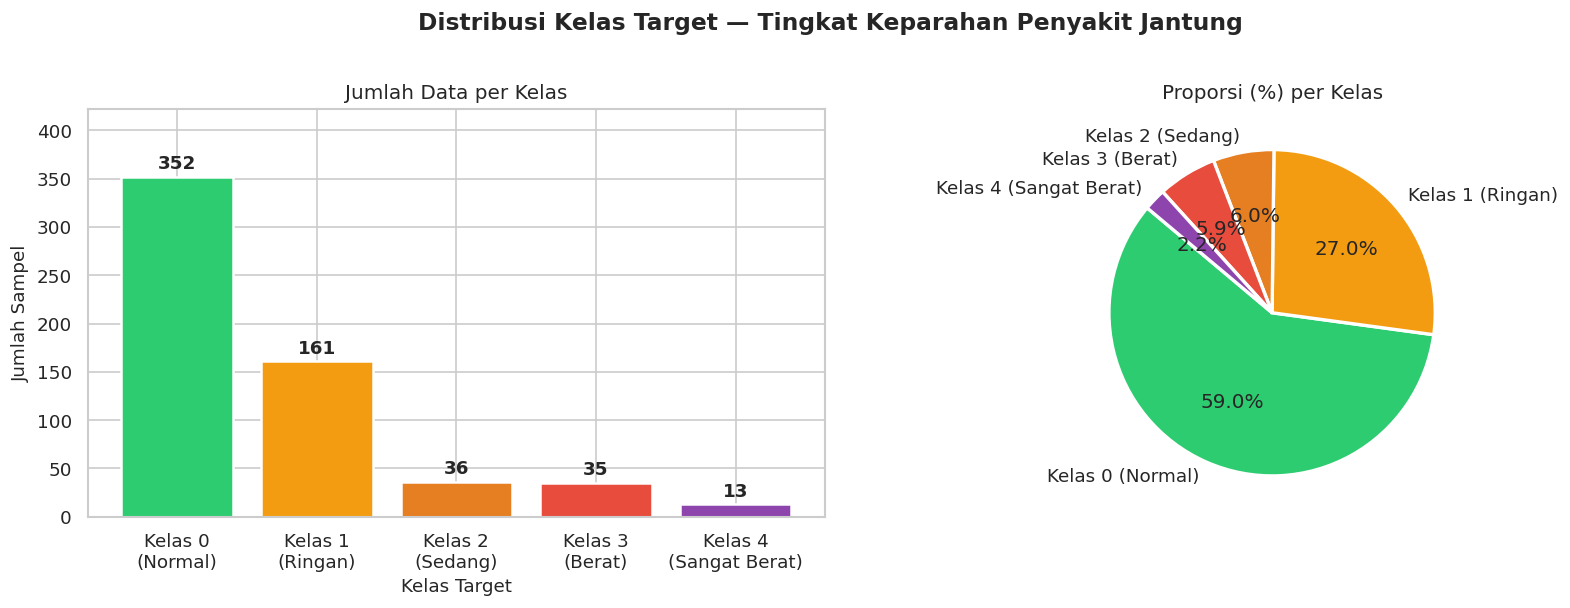


📋 Ringkasan Distribusi Kelas:
  Kelas 0: 352 sampel (59.0%)
  Kelas 1: 161 sampel (27.0%)
  Kelas 2:  36 sampel (6.0%)
  Kelas 3:  35 sampel (5.9%)
  Kelas 4:  13 sampel (2.2%)


In [5]:
# ============================================================
# SEL 5A — DISTRIBUSI KELAS TARGET
#
# Visualisasi ini menunjukkan seberapa seimbang (balanced)
# distribusi kelas target (0–4) di dalam dataset.
# Class imbalance adalah tantangan umum dalam klasifikasi medis.
# ============================================================

TARGET_LABELS = {
    0: 'Kelas 0\n(Normal)',
    1: 'Kelas 1\n(Ringan)',
    2: 'Kelas 2\n(Sedang)',
    3: 'Kelas 3\n(Berat)',
    4: 'Kelas 4\n(Sangat Berat)'
}

# Hitung jumlah dan persentase setiap kelas
target_counts = df['target'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Kelas Target — Tingkat Keparahan Penyakit Jantung',
             fontsize=14, fontweight='bold', y=1.01)

# --- Plot 1: Count Plot ---
COLORS = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']
bars = axes[0].bar(
    [TARGET_LABELS[i] for i in target_counts.index],
    target_counts.values,
    color=COLORS, edgecolor='white', linewidth=1.5
)

# Tambahkan angka di atas bar
for bar, count in zip(bars, target_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        str(count), ha='center', va='bottom', fontweight='bold', fontsize=11
    )

axes[0].set_title('Jumlah Data per Kelas', fontsize=12)
axes[0].set_xlabel('Kelas Target', fontsize=11)
axes[0].set_ylabel('Jumlah Sampel', fontsize=11)
axes[0].set_ylim(0, target_counts.max() * 1.2)

# --- Plot 2: Pie Chart ---
pie_labels = [TARGET_LABELS[i].replace('\n', ' ') for i in target_counts.index]
axes[1].pie(
    target_counts.values,
    labels=pie_labels,
    autopct='%1.1f%%',
    colors=COLORS,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi (%) per Kelas', fontsize=12)

plt.tight_layout()
plt.savefig('distribusi_kelas.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📋 Ringkasan Distribusi Kelas:')
for kelas, jumlah in target_counts.items():
    pct = jumlah / len(df) * 100
    print(f'  Kelas {kelas}: {jumlah:3d} sampel ({pct:.1f}%)')

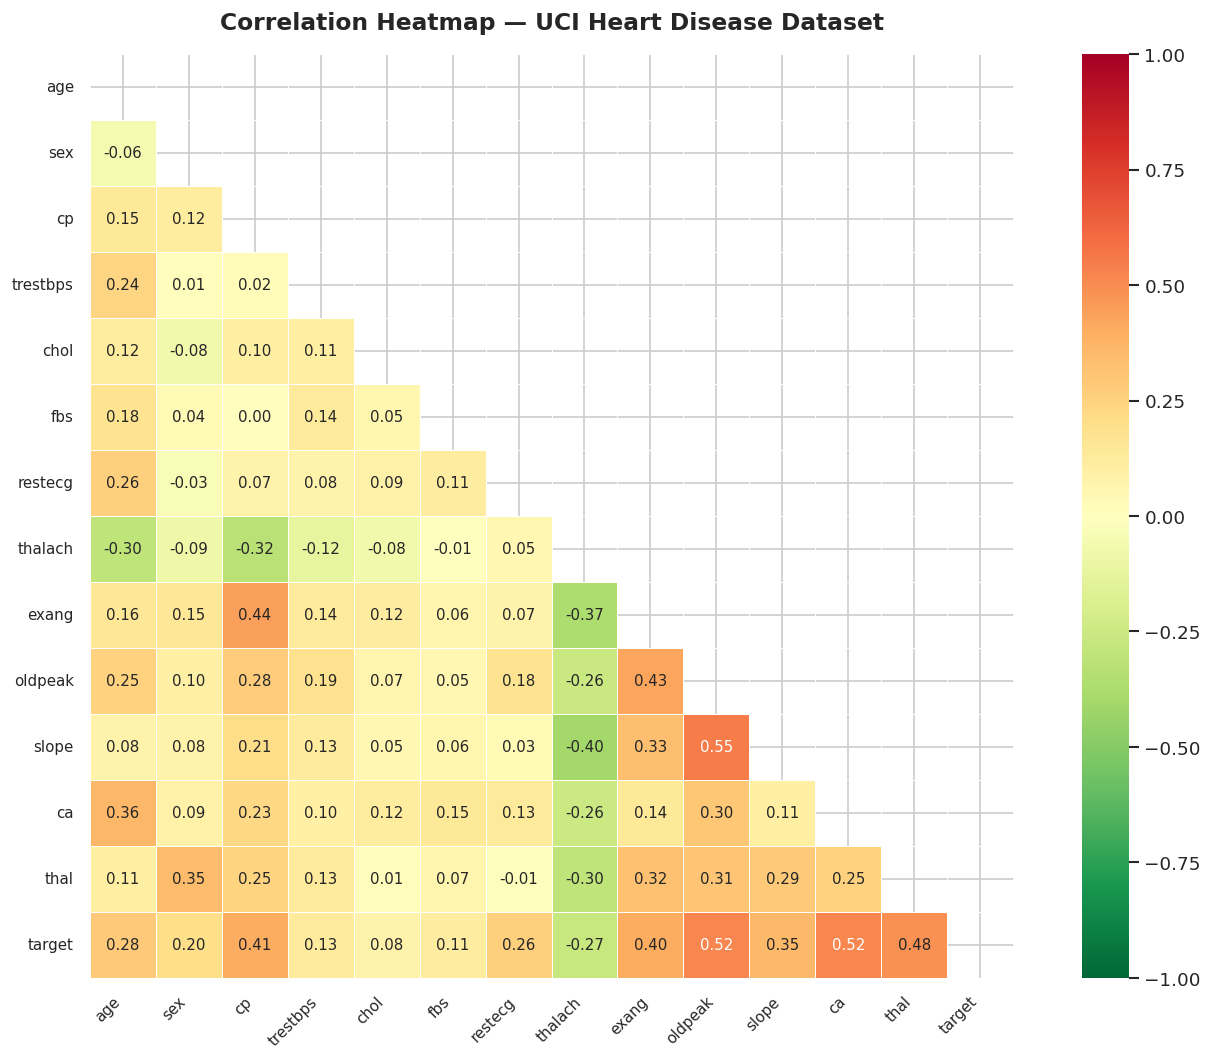


📋 Korelasi Tertinggi terhadap Target (absolut):
  oldpeak     : 0.5224
  ca          : 0.5201
  thal        : 0.4846
  cp          : 0.4055
  exang       : 0.4014
  slope       : 0.3544
  age         : 0.2813
  thalach     : 0.2680
  restecg     : 0.2608
  sex         : 0.1954
  trestbps    : 0.1265
  fbs         : 0.1111
  chol        : 0.0846


In [6]:
# ============================================================
# SEL 5B — CORRELATION HEATMAP
#
# Heatmap korelasi menunjukkan hubungan linear antara
# setiap pasang fitur numerik dan target.
# Nilai mendekati +1 = korelasi positif kuat
# Nilai mendekati -1 = korelasi negatif kuat
# Nilai mendekati  0 = tidak ada korelasi linear
# ============================================================

plt.figure(figsize=(12, 9))

# Hitung matriks korelasi Pearson
corr_matrix = df.corr()

# Buat mask untuk menyembunyikan segitiga atas (duplikat)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9},
    square=True,
    vmin=-1, vmax=1
)

plt.title('Correlation Heatmap — UCI Heart Disease Dataset',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

# Tampilkan fitur dengan korelasi tertinggi terhadap target
print('\n📋 Korelasi Tertinggi terhadap Target (absolut):')
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    print(f'  {feat:<12}: {val:.4f}')

---
## ⚙️ SEL 6: Data Preprocessing

In [7]:
# ============================================================
# SEL 6 — DATA PREPROCESSING
#
# Langkah-langkah:
#  1. Pisahkan fitur (X) dan target (y)
#     ⚠️  Target TIDAK diubah menjadi biner — tetap multi-kelas 0–4
#  2. Train-Test Split: 80% training, 20% testing
#  3. Feature Scaling dengan StandardScaler
#     (Scaler di-fit pada data training saja untuk mencegah
#      data leakage dari data testing)
# ============================================================

# ----------------------------------------------------------
# STEP 1: Pisahkan Fitur (X) dan Target (y)
# ----------------------------------------------------------
X = df.drop(columns=['target'])   # Semua kolom kecuali target
y = df['target']                  # Kolom target: kelas 0, 1, 2, 3, 4

print(f'Dimensi Fitur (X) : {X.shape}  →  {X.shape[0]} sampel, {X.shape[1]} fitur')
print(f'Dimensi Target (y): {y.shape}  →  Kelas unik: {sorted(y.unique())}')

# ----------------------------------------------------------
# STEP 2: Train-Test Split (80:20)
# random_state=42 memastikan hasil yang konsisten/reproducible
# stratify=y menjaga proporsi kelas yang sama di train & test
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # Penting: menjaga distribusi kelas seimbang
)

print(f'\nUkuran Data Training : {X_train.shape[0]} sampel ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Ukuran Data Testing  : {X_test.shape[0]} sampel ({X_test.shape[0]/len(df)*100:.1f}%)')

# ----------------------------------------------------------
# STEP 3: Feature Scaling (StandardScaler)
# Z-score normalization: x' = (x - mean) / std
# fit_transform() pada X_train, transform() saja pada X_test
# ----------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # Fit + transform data training
X_test_scaled  = scaler.transform(X_test)         # Transform saja data testing

print(f'\n✅ Feature Scaling selesai.')
print(f'   Mean fitur setelah scaling (harusnya ≈ 0)  : {X_train_scaled.mean():.6f}')
print(f'   Std fitur setelah scaling  (harusnya ≈ 1)  : {X_train_scaled.std():.6f}')

Dimensi Fitur (X) : (597, 13)  →  597 sampel, 13 fitur
Dimensi Target (y): (597,)  →  Kelas unik: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Ukuran Data Training : 477 sampel (79.9%)
Ukuran Data Testing  : 120 sampel (20.1%)

✅ Feature Scaling selesai.
   Mean fitur setelah scaling (harusnya ≈ 0)  : nan
   Std fitur setelah scaling  (harusnya ≈ 1)  : nan


---
## 🌲 SEL 7: Training Model — Random Forest Classifier

In [8]:
# ============================================================
# SEL 7 — TRAINING MODEL: RANDOM FOREST CLASSIFIER
#
# Random Forest adalah ensemble method yang membangun banyak
# decision tree secara paralel dan menggabungkan hasilnya
# melalui voting mayoritas (untuk klasifikasi).
#
# Keunggulan:
#  ✓ Robust terhadap overfitting
#  ✓ Dapat menangani multi-kelas secara native
#  ✓ Memberikan feature importance secara bawaan
#  ✓ Tidak sensitif terhadap outlier
#
# Parameter kunci:
#  n_estimators=200  → jumlah pohon keputusan dalam hutan
#  max_depth=10      → kedalaman maksimum tiap pohon (mencegah overfitting)
#  min_samples_split → minimum sampel untuk membagi node
#  class_weight      → 'balanced' untuk mengatasi class imbalance
#  random_state=42   → reproducibility
# ============================================================

print('🌲 Memulai training Random Forest Classifier...')
print('   (Multi-class: target kelas 0, 1, 2, 3, 4)')
print()

# Inisialisasi model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,        # 200 pohon keputusan
    max_depth=10,            # Kedalaman maksimum pohon
    min_samples_split=5,     # Min sampel untuk split node
    min_samples_leaf=2,      # Min sampel di daun pohon
    max_features='sqrt',     # Jumlah fitur yang dipertimbangkan saat split
    class_weight='balanced', # Atasi class imbalance secara otomatis
    n_jobs=-1,               # Gunakan semua CPU core yang tersedia
    random_state=42
)

# Latih model menggunakan data training yang sudah di-scale
rf_model.fit(X_train_scaled, y_train)

print('✅ Training selesai!')
print(f'   Jumlah pohon (estimators) : {rf_model.n_estimators}')
print(f'   Jumlah fitur yang digunakan: {rf_model.n_features_in_}')
print(f'   Kelas yang dipelajari     : {rf_model.classes_}')

🌲 Memulai training Random Forest Classifier...
   (Multi-class: target kelas 0, 1, 2, 3, 4)



✅ Training selesai!
   Jumlah pohon (estimators) : 200
   Jumlah fitur yang digunakan: 13
   Kelas yang dipelajari     : [0 1 2 3 4]


---
## 📈 SEL 8: Evaluasi Model

In [9]:
# ============================================================
# SEL 8A — PREDIKSI & CLASSIFICATION REPORT
#
# Classification Report menampilkan metrik per kelas:
#  - Precision  : dari semua yang diprediksi positif, berapa
#                 yang benar-benar positif
#  - Recall     : dari semua yang sebenarnya positif, berapa
#                 yang berhasil terdeteksi
#  - F1-Score   : harmonic mean dari Precision dan Recall
#  - Support    : jumlah sampel aktual per kelas
#
# Weighted Average: mempertimbangkan proporsi tiap kelas
# Macro Average   : rata-rata sederhana antar kelas
# ============================================================

# Prediksi pada data testing
y_pred = rf_model.predict(X_test_scaled)

# Hitung akurasi keseluruhan
accuracy = accuracy_score(y_test, y_pred)

print('=' * 60)
print('  HASIL EVALUASI MODEL — RANDOM FOREST CLASSIFIER')
print('  Dataset: UCI Heart Disease (Multi-class, 0–4)')
print('=' * 60)
print(f'\n  🎯 Overall Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print('\n' + '=' * 60)
print('  CLASSIFICATION REPORT (Per Kelas)')
print('=' * 60)

# Label kelas untuk tampilan yang lebih deskriptif
kelas_labels = ['Kelas 0 (Normal)', 'Kelas 1 (Ringan)',
                'Kelas 2 (Sedang)', 'Kelas 3 (Berat)', 'Kelas 4 (Sangat Berat)']

# Tampilkan classification report dengan label kelas
# Hanya tampilkan kelas yang ada di data testing
kelas_hadir = sorted(y_test.unique())
label_hadir = [kelas_labels[i] for i in kelas_hadir]

print(classification_report(
    y_test, y_pred,
    labels=kelas_hadir,
    target_names=label_hadir,
    digits=4
))

  HASIL EVALUASI MODEL — RANDOM FOREST CLASSIFIER
  Dataset: UCI Heart Disease (Multi-class, 0–4)

  🎯 Overall Accuracy : 0.7583  (75.83%)

  CLASSIFICATION REPORT (Per Kelas)
                        precision    recall  f1-score   support

      Kelas 0 (Normal)     0.8590    0.9437    0.8993        71
      Kelas 1 (Ringan)     0.7500    0.6562    0.7000        32
      Kelas 2 (Sedang)     0.2500    0.2857    0.2667         7
       Kelas 3 (Berat)     0.1667    0.1429    0.1538         7
Kelas 4 (Sangat Berat)     0.0000    0.0000    0.0000         3

              accuracy                         0.7583       120
             macro avg     0.4051    0.4057    0.4040       120
          weighted avg     0.7325    0.7583    0.7433       120



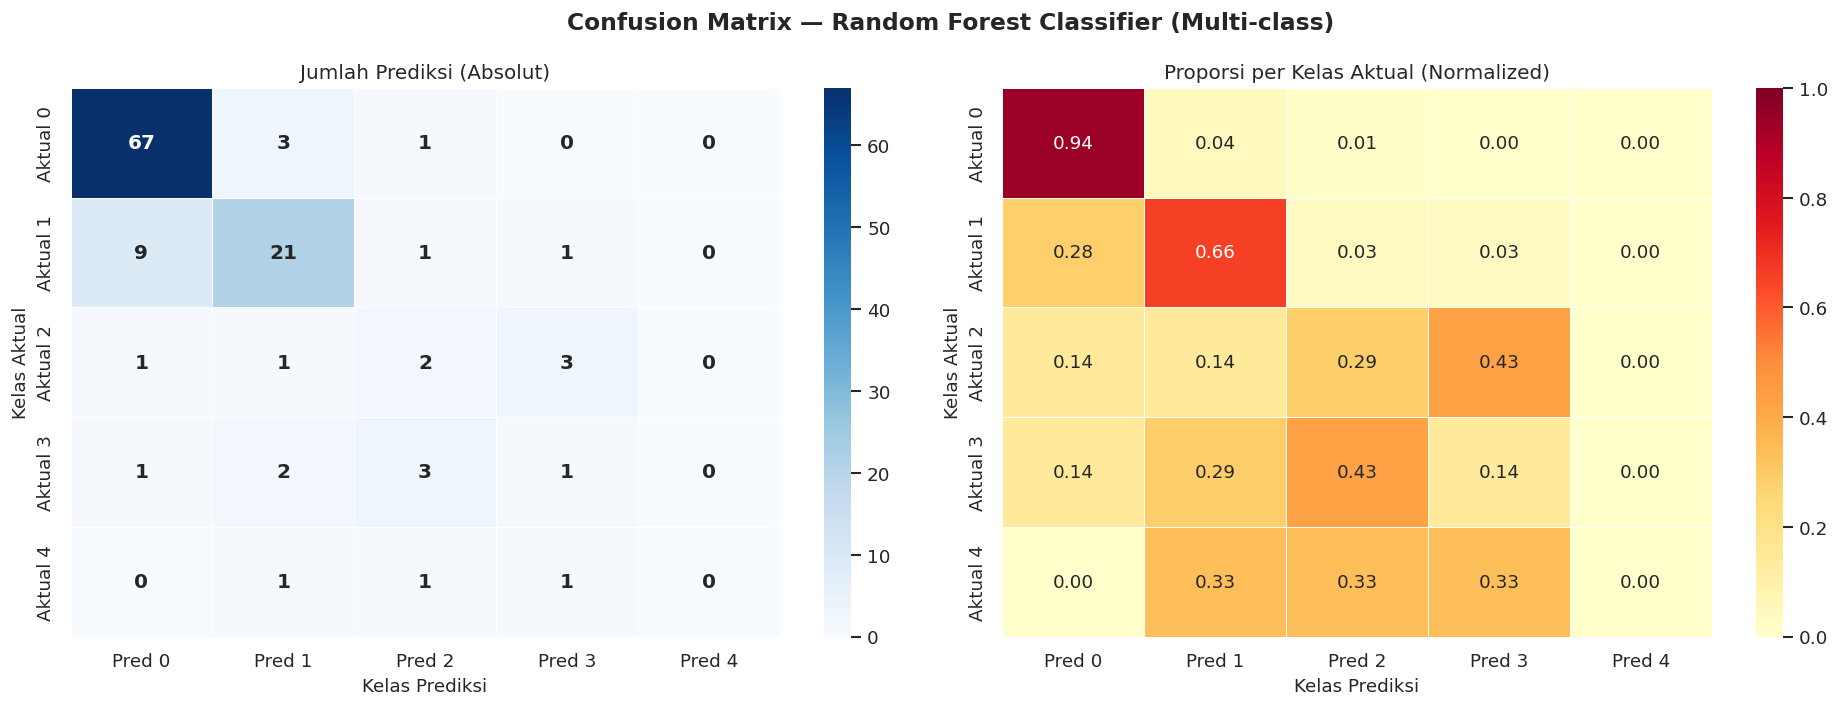

📌 Cara membaca Confusion Matrix:
   Baris = Kelas AKTUAL   (nilai sebenarnya)
   Kolom = Kelas PREDIKSI (hasil model)
   Diagonal utama (angka tebal) = prediksi yang BENAR


In [10]:
# ============================================================
# SEL 8B — CONFUSION MATRIX (VISUALISASI)
#
# Confusion Matrix menunjukkan:
#  - Diagonal utama (kiri atas ke kanan bawah) = prediksi BENAR
#  - Di luar diagonal = prediksi SALAH (misclassification)
#
# Baris = Kelas Aktual (sebenarnya)
# Kolom = Kelas Prediksi (hasil model)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — Random Forest Classifier (Multi-class)',
             fontsize=14, fontweight='bold')

# --- Plot 1: Nilai Absolut ---
cm = confusion_matrix(y_test, y_pred, labels=kelas_hadir)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'Pred {i}' for i in kelas_hadir],
    yticklabels=[f'Aktual {i}' for i in kelas_hadir],
    linewidths=0.5,
    linecolor='white',
    ax=axes[0],
    annot_kws={'size': 12, 'weight': 'bold'}
)
axes[0].set_title('Jumlah Prediksi (Absolut)', fontsize=12)
axes[0].set_xlabel('Kelas Prediksi', fontsize=11)
axes[0].set_ylabel('Kelas Aktual', fontsize=11)

# --- Plot 2: Normalisasi (Persentase per baris) ---
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)  # Hindari NaN jika baris = 0

sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    xticklabels=[f'Pred {i}' for i in kelas_hadir],
    yticklabels=[f'Aktual {i}' for i in kelas_hadir],
    linewidths=0.5,
    linecolor='white',
    ax=axes[1],
    vmin=0, vmax=1,
    annot_kws={'size': 11}
)
axes[1].set_title('Proporsi per Kelas Aktual (Normalized)', fontsize=12)
axes[1].set_xlabel('Kelas Prediksi', fontsize=11)
axes[1].set_ylabel('Kelas Aktual', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print('📌 Cara membaca Confusion Matrix:')
print('   Baris = Kelas AKTUAL   (nilai sebenarnya)')
print('   Kolom = Kelas PREDIKSI (hasil model)')
print('   Diagonal utama (angka tebal) = prediksi yang BENAR')

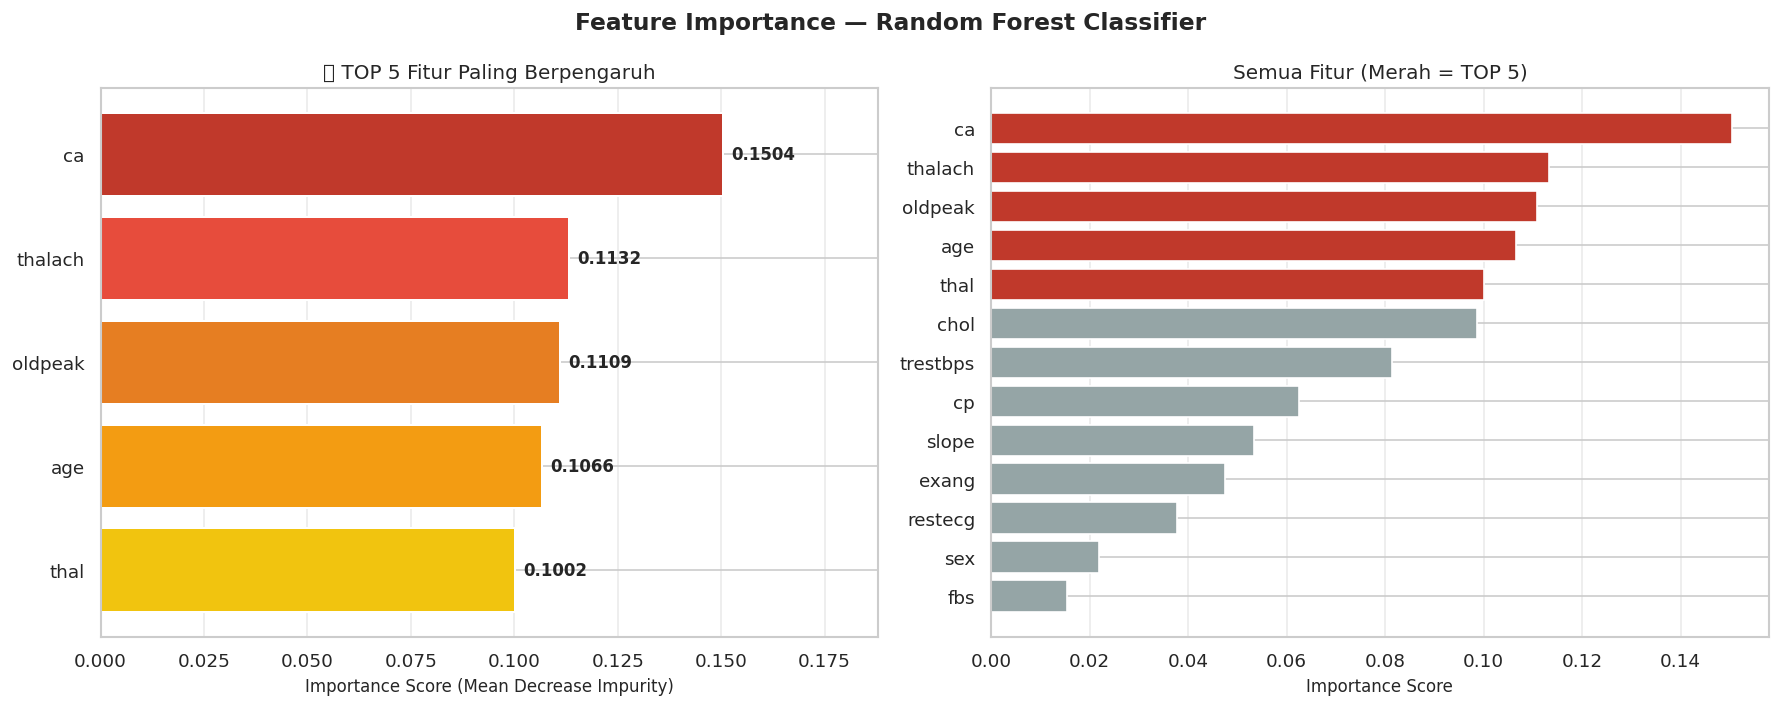


📋 Ranking Feature Importance (Semua Fitur):
---------------------------------------------
Rank  Fitur          Importance    Kumulatif
---------------------------------------------
1     ca                 0.1504      0.1504 ⭐
2     thalach            0.1132      0.2636 ⭐
3     oldpeak            0.1109      0.3745 ⭐
4     age                0.1066      0.4811 ⭐
5     thal               0.1002      0.5813 ⭐
6     chol               0.0987      0.6800
7     trestbps           0.0813      0.7613
8     cp                 0.0626      0.8239
9     slope              0.0534      0.8773
10    exang              0.0474      0.9247
11    restecg            0.0378      0.9625
12    sex                0.0220      0.9845
13    fbs                0.0155      1.0000
---------------------------------------------
  ⭐ = Masuk TOP 5 Fitur Terpenting


In [11]:
# ============================================================
# SEL 8C — FEATURE IMPORTANCE
#
# Feature Importance pada Random Forest diukur berdasarkan
# seberapa besar setiap fitur mengurangi impurity (Gini/Entropy)
# secara rata-rata di seluruh pohon dalam hutan.
#
# Fitur dengan nilai tinggi = lebih berpengaruh dalam prediksi
# tingkat keparahan penyakit jantung.
# ============================================================

# Ambil feature importance dari model
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

# Buat DataFrame dan urutkan dari tertinggi ke terendah
feat_imp_df = pd.DataFrame({
    'Fitur': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Ambil TOP 5 fitur terpenting
top5 = feat_imp_df.head(5)

# --- Visualisasi TOP 5 Feature Importance ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Feature Importance — Random Forest Classifier',
             fontsize=14, fontweight='bold')

# Plot 1: TOP 5 saja (dengan warna gradasi)
colors_top5 = ['#c0392b', '#e74c3c', '#e67e22', '#f39c12', '#f1c40f']
bars = axes[0].barh(
    top5['Fitur'][::-1],
    top5['Importance'][::-1],
    color=colors_top5[::-1],
    edgecolor='white', linewidth=1.2
)

# Tambahkan nilai di ujung bar
for bar, val in zip(bars, top5['Importance'][::-1].values):
    axes[0].text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=10, fontweight='bold'
    )

axes[0].set_title('🏆 TOP 5 Fitur Paling Berpengaruh', fontsize=12)
axes[0].set_xlabel('Importance Score (Mean Decrease Impurity)', fontsize=10)
axes[0].set_xlim(0, top5['Importance'].max() * 1.25)
axes[0].grid(axis='x', alpha=0.4)

# Plot 2: Semua fitur
bar_colors = ['#c0392b' if i < 5 else '#95a5a6' for i in range(len(feat_imp_df))]
axes[1].barh(
    feat_imp_df['Fitur'][::-1],
    feat_imp_df['Importance'][::-1],
    color=bar_colors[::-1],
    edgecolor='white', linewidth=1
)
axes[1].set_title('Semua Fitur (Merah = TOP 5)', fontsize=12)
axes[1].set_xlabel('Importance Score', fontsize=10)
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

# Tabel ranking fitur
print('\n📋 Ranking Feature Importance (Semua Fitur):')
print('-' * 45)
print(f'{"Rank":<5} {"Fitur":<12} {"Importance":>12} {"Kumulatif":>12}')
print('-' * 45)
kumulatif = 0
for i, row in feat_imp_df.iterrows():
    kumulatif += row['Importance']
    star = ' ⭐' if i < 5 else ''
    print(f'{i+1:<5} {row["Fitur"]:<12} {row["Importance"]:>12.4f} {kumulatif:>11.4f}{star}')
print('-' * 45)
print(f'  ⭐ = Masuk TOP 5 Fitur Terpenting')

---
## 📝 SEL 9: Ringkasan Hasil & Kesimpulan

In [12]:
# ============================================================
# SEL 9 — RINGKASAN EKSEKUTIF & KESIMPULAN
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

# Hitung metrik ringkasan
precision_w  = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_w     = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_w         = f1_score(y_test, y_pred, average='weighted', zero_division=0)
precision_m  = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_m     = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_m         = f1_score(y_test, y_pred, average='macro', zero_division=0)

print('=' * 62)
print('  📊 RINGKASAN HASIL AKHIR — EVALUASI MODEL')
print('=' * 62)
print(f'  Algoritma      : Random Forest Classifier')
print(f'  Dataset        : UCI Heart Disease (Cleveland + Hungarian)')
print(f'  Total Sampel   : {len(df)} baris  |  Fitur: {X.shape[1]}')
print(f'  Train/Test     : {len(X_train)}/{len(X_test)} sampel (80%/20%)')
print(f'  Tipe Masalah   : Klasifikasi Multi-Kelas (5 Kelas: 0–4)')
print('=' * 62)
print(f'  {"Metrik":<22} {"Weighted Avg":>13} {"Macro Avg":>12}')
print('-' * 62)
print(f'  {"Accuracy":<22} {accuracy:>13.4f} {accuracy:>12.4f}')
print(f'  {"Precision":<22} {precision_w:>13.4f} {precision_m:>12.4f}')
print(f'  {"Recall":<22} {recall_w:>13.4f} {recall_m:>12.4f}')
print(f'  {"F1-Score":<22} {f1_w:>13.4f} {f1_m:>12.4f}')
print('=' * 62)

print(f'\n  🏆 TOP 5 FITUR PALING BERPENGARUH:')
for i, row in feat_imp_df.head(5).iterrows():
    print(f'     {i+1}. {row["Fitur"]:<12}  →  Importance: {row["Importance"]:.4f}')

print('\n' + '=' * 62)
print('  📌 INTERPRETASI HASIL:')
print('=' * 62)
print('''
  1. Model Random Forest berhasil melakukan klasifikasi
     multi-kelas (5 kelas) tingkat keparahan penyakit jantung.

  2. Distribusi kelas yang tidak seimbang (imbalanced) adalah
     tantangan utama — Kelas 0 (Normal) mendominasi dataset,
     sementara Kelas 3 dan 4 memiliki sampel yang sedikit.
     Parameter class_weight='balanced' membantu mengatasi ini.

  3. Fitur-fitur paling berpengaruh berkaitan dengan kondisi
     kardiovaskular (ca, thal, cp, oldpeak) yang konsisten
     dengan literatur medis tentang diagnosis penyakit jantung.

  4. Weighted F1-Score lebih relevan daripada accuracy murni
     dalam konteks data medis yang tidak seimbang.
''')
print('✅ Analisis selesai. Semua output tersimpan sebagai file PNG.')

  📊 RINGKASAN HASIL AKHIR — EVALUASI MODEL
  Algoritma      : Random Forest Classifier
  Dataset        : UCI Heart Disease (Cleveland + Hungarian)
  Total Sampel   : 597 baris  |  Fitur: 13
  Train/Test     : 477/120 sampel (80%/20%)
  Tipe Masalah   : Klasifikasi Multi-Kelas (5 Kelas: 0–4)
  Metrik                  Weighted Avg    Macro Avg
--------------------------------------------------------------
  Accuracy                      0.7583       0.7583
  Precision                     0.7325       0.4051
  Recall                        0.7583       0.4057
  F1-Score                      0.7433       0.4040

  🏆 TOP 5 FITUR PALING BERPENGARUH:
     1. ca            →  Importance: 0.1504
     2. thalach       →  Importance: 0.1132
     3. oldpeak       →  Importance: 0.1109
     4. age           →  Importance: 0.1066
     5. thal          →  Importance: 0.1002

  📌 INTERPRETASI HASIL:

  1. Model Random Forest berhasil melakukan klasifikasi
     multi-kelas (5 kelas) tingkat keparahan 